#**sentiment Model**

In [1]:
#import pandas as pd
#import numpy as np
#import nltk
#nltk.download('stopwords')
#from nltk.corpus import stopwords
#nltk.download('punk')

#import re
#import string
#from nltk.tokenize import TweetTokenizer
#from sklearn.model_selection import train_test_split

#from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay, roc_auc_score
#from nltk.stem import WordNetLemmatizer

#from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.naive_bayes import MultinomialNB
#import matplotlib.pyplot as plt

# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import  CountVectorizer #TfidfVectorizer
#from sklearn.pipeline import Pipeline
#from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
# ==============================
# 2. Load Data (UPDATE PATHS)
# ==============================
df1 = pd.read_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/scored_tweets_total.csv", usecols=["text", "Sentiment"])
df1 = df1[df1['Sentiment'] != 0]

df2 = pd.read_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/stock_data.csv")
df2.columns = ["text", "Sentiment"]

df3 = pd.read_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/stock_tweet_sentiment.csv", usecols=["text", "Sentiment"])
df3 = df3[df3['Sentiment'] != 0]

df4 = pd.read_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/tweets_labelled.csv", sep=';', on_bad_lines='skip')
df4['Sentiment'] = df4['sentiment'].replace(
    ["positive", "neutral", "negative"], [1, 0, -1]
)
df4 = df4[['text', 'Sentiment']]
df4 = df4[df4['Sentiment'] != 0]
df4.dropna(inplace=True)

# Combine all datasets
data = pd.concat([df1, df2, df3, df4], ignore_index=True)

/tmp/ipykernel_20655/1141055238.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['Sentiment'] = df4['sentiment'].replace(


In [3]:
# ==============================
# 3. Preprocessing Function
# ==============================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

def clean_text(text):
    text = re.sub(r'^RT[\s]+', '', text)           # Remove RT
    text = re.sub(r'https?:\/\/\S+', '', text)     # Remove URLs
    text = re.sub(r'\d+', '', text)                # Remove numbers
    text = re.sub(r'#', '', text)                  # Remove #
    text = re.sub(r'[^\w\s]', '', text)            # Remove punctuation

    tokens = tokenizer.tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

# Apply cleaning
data['clean_text'] = data['text'].apply(clean_text)


In [4]:
data

,text,Sentiment,clean_text
0,$AXTG Big OTC % Gainer!🚀🚀🚀,1.0,axtg big otc gainer
1,Today’s Top Penny Stock Gainers\n\n$LTTGF $AXT...,1.0,today top penny stock gainer lttgf axtg seva a...
2,RT @GetScanz: Today’s Top Penny Stock Gainers\...,1.0,getscanz today top penny stock gainer lttgf ax...
3,RT @GetScanz: Today’s Top Penny Stock Gainers\...,1.0,getscanz today top penny stock gainer lttgf ax...
4,That is a great point! NFT is huge and $HMBL h...,1.0,great point nft huge hmbl tool place become pl...
...,...,...,...
26943,Q3 2020 EPS Estimates for Ball Co. $BLL Increa...,1.0,eps estimate ball bll increased analyst stock
26944,#stocks back from the recovery room: https://t...,1.0,stock back recovery room fair value fairly pri...
26945,RT @MacroCharts: Breadth – expanding last week...,1.0,macrocharts breadth expanding last week discus...
26946,$AAPL $QQQ Top may now be in. https://t.co/iNK...,1.0,aapl qqq top may


In [5]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['clean_text'])
vectorizer.get_feature_names_out()



array(['___', '___camjones', '___jgrsgrepublic', ...,
       '購入シングルステーキングにぶち込みました', '運営からの寄付を上', '𝗕𝗘𝗧𝗔'], dtype=object)

In [6]:
#split into train test

y = data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify = y, test_size= .1, random_state= 42)

In [7]:
print(type(X_train))
print(X_train.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(24253, 21552)


In [8]:

clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

Accuracy Score:  0.8690166975881262


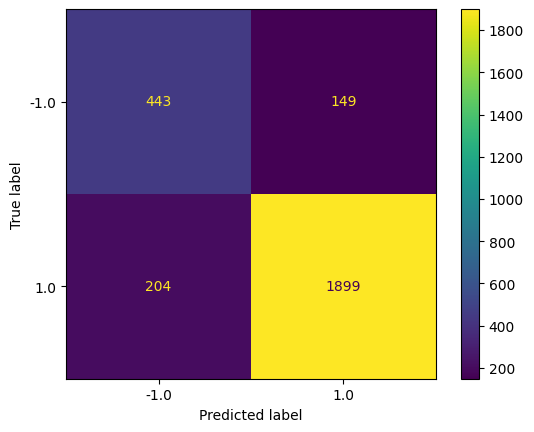

In [9]:
y_pred = clf.predict(X_test)
print('Accuracy Score: ',accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

[[3.44127817e-06 9.99996559e-01]
 [1.26051775e-01 8.73948225e-01]
 [2.09268362e-02 9.79073164e-01]
 ...
 [9.99995196e-01 4.80404800e-06]
 [8.48090975e-01 1.51909025e-01]
 [2.85633435e-01 7.14366565e-01]]


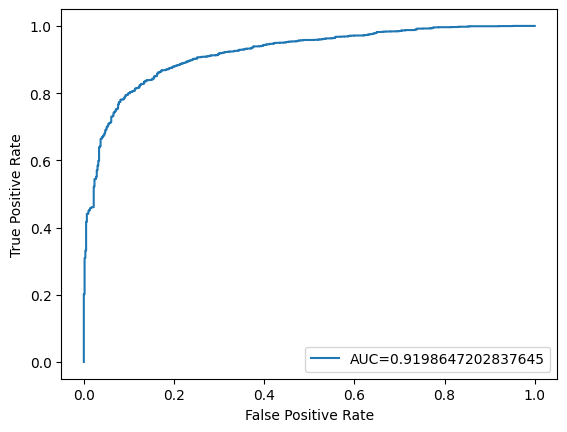

In [10]:

pred = clf.predict_proba(X_test)
print(pred)
fpr, tpr, thresholds = roc_curve(y_test, pred[:,1])
auc = roc_auc_score(y_test, pred[:,1])
plt.plot(fpr, tpr,label="AUC="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

In [13]:

df = pd.read_csv('/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/nifty50tweets.csv')
df.rename(columns = {'Text':'Tweet'}, inplace = True)
df

/tmp/ipykernel_20655/79198815.py:1: DtypeWarning: Columns (0,1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/nifty50tweets.csv')


,Unnamed: 0,Date Created,Number of Likes,Tweet
0,0,2022-10-12,11.0,Domestic equity market behaved decoupled from ...
1,1,2022-10-12,0.0,💰FII &amp; DII Buying &amp; Selling in the cas...
2,2,2022-10-12,30.0,NIFTY 50 (Daily): Three interesting patterns w...
3,3,2022-10-12,37.0,12-10-2022\n\nAlthough the indices re bounded ...
4,4,2022-10-12,9.0,Karur Vysya bank #karurvysya \nThis is one of ...
...,...,...,...,...
399860,142034,2017-10-13,0.0,Dynamic Levels: Support and resistance levels ...
399861,142035,2017-10-13,0.0,India stocks higher at close of trade; Nifty 5...
399862,142036,2017-10-13,0.0,"Nifty50 scales record highs, Sensex closes 250..."
399863,142037,2017-10-13,0.0,Tech View: Nifty50 makes strong bullish candle...


In [14]:

df['Tweet'] = df['Tweet'].apply(lambda cw : clean_text(str(cw)))          #see above code
df['Tweet'] = df['Tweet'].apply(lambda cw : vectorizer.transform([cw]))   # see above code
df['Sentiment_pred'] = df['Tweet'].apply(lambda cw :  clf.predict(cw))    # nbnomial code see above
df['Sentiment_pred'] = df['Sentiment_pred'].apply(lambda cw :  int(cw))
df


/tmp/ipykernel_20655/3121124227.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df['Sentiment_pred'] = df['Sentiment_pred'].apply(lambda cw :  int(cw))


,Unnamed: 0,Date Created,Number of Likes,Tweet,Sentiment_pred
0,0,2022-10-12,11.0,<Compressed Sparse Row sparse matrix of dtype ...,-1
1,1,2022-10-12,0.0,<Compressed Sparse Row sparse matrix of dtype ...,1
2,2,2022-10-12,30.0,<Compressed Sparse Row sparse matrix of dtype ...,1
3,3,2022-10-12,37.0,<Compressed Sparse Row sparse matrix of dtype ...,-1
4,4,2022-10-12,9.0,<Compressed Sparse Row sparse matrix of dtype ...,1
...,...,...,...,...,...
399860,142034,2017-10-13,0.0,<Compressed Sparse Row sparse matrix of dtype ...,1
399861,142035,2017-10-13,0.0,<Compressed Sparse Row sparse matrix of dtype ...,-1
399862,142036,2017-10-13,0.0,<Compressed Sparse Row sparse matrix of dtype ...,-1
399863,142037,2017-10-13,0.0,<Compressed Sparse Row sparse matrix of dtype ...,1


In [15]:

t = df.sort_values(['Date Created', 'Number of Likes'],ascending=False).groupby("Date Created").head(10).reset_index()
t.dropna(inplace=True)
t = t[['Date Created', 'Sentiment_pred']]
t

,Date Created,Sentiment_pred
0,2022-10-12,-1
1,2022-10-12,-1
2,2022-10-12,1
3,2022-10-12,1
4,2022-10-12,-1
...,...,...
18190,2017-10-13,-1
18191,2017-10-13,-1
18192,2017-10-13,-1
18193,2017-10-13,-1


In [16]:

final_df = t.groupby('Date Created').agg(tuple).applymap(list).reset_index()[["Date Created", "Sentiment_pred"]]
final_df

/tmp/ipykernel_20655/3797300021.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  final_df = t.groupby('Date Created').agg(tuple).applymap(list).reset_index()[["Date Created", "Sentiment_pred"]]


,Date Created,Sentiment_pred
0,2017-10-13,"[1, -1, 1, 1, -1, -1, -1, -1, -1, -1]"
1,2017-10-14,"[1, -1, 1, -1, 1, -1, -1, 1, -1, 1]"
2,2017-10-15,"[-1, 1, 1, 1, 1, 1, 1, 1, -1]"
3,2017-10-16,"[1, 1, -1, -1, -1, -1, -1, -1, -1, 1]"
4,2017-10-17,"[1, 1, -1, -1, 1, 1, -1, 1, -1, -1]"
...,...,...
1820,2022-10-08,"[-1, 1, -1, 1, -1, -1, 1, -1, -1, -1]"
1821,2022-10-09,"[-1, 1, 1, 1, -1, 1, -1, 1, -1, 1]"
1822,2022-10-10,"[1, 1, -1, -1, -1, 1, -1, -1, -1, -1]"
1823,2022-10-11,"[-1, -1, 1, 1, 1, 1, 1, 1, 1, 1]"


In [17]:

final_df['Mode'] = final_df['Sentiment_pred'].apply(lambda cw :  max(set(cw), key=cw.count))
final_df

,Date Created,Sentiment_pred,Mode
0,2017-10-13,"[1, -1, 1, 1, -1, -1, -1, -1, -1, -1]",-1
1,2017-10-14,"[1, -1, 1, -1, 1, -1, -1, 1, -1, 1]",1
2,2017-10-15,"[-1, 1, 1, 1, 1, 1, 1, 1, -1]",1
3,2017-10-16,"[1, 1, -1, -1, -1, -1, -1, -1, -1, 1]",-1
4,2017-10-17,"[1, 1, -1, -1, 1, 1, -1, 1, -1, -1]",1
...,...,...,...
1820,2022-10-08,"[-1, 1, -1, 1, -1, -1, 1, -1, -1, -1]",-1
1821,2022-10-09,"[-1, 1, 1, 1, -1, 1, -1, 1, -1, 1]",1
1822,2022-10-10,"[1, 1, -1, -1, -1, 1, -1, -1, -1, -1]",-1
1823,2022-10-11,"[-1, -1, 1, 1, 1, 1, 1, 1, 1, 1]",1


In [20]:
final_df.to_csv("/content/drive/MyDrive/data sets for  ml/csv_files for creat dataset/final_sentiments.csv")